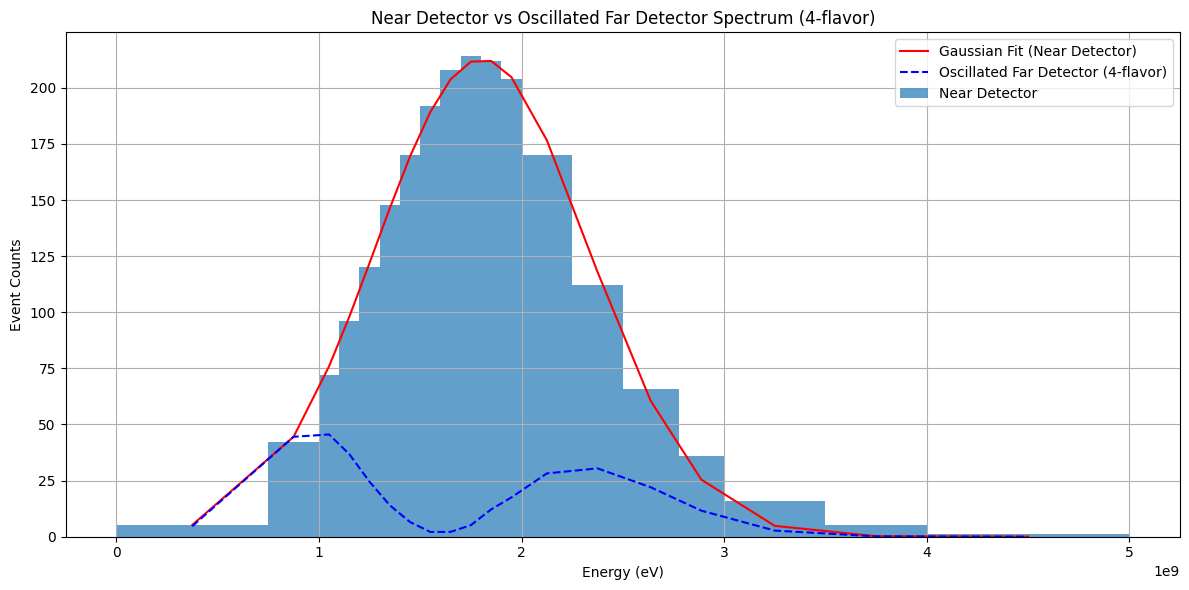

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit

# Constants
CONV_KM_TO_INV_EV = 5.067731e9  # Conversion factor from km to inverse eV
VCC_EARTH_CRUST = 7.6e-14  # Matter potential in eV

# Define mixing matrix elements
def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

# Define Hamiltonian
def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])  # Mass squared differences
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    H_vacuum = U @ m2_diag @ np.conj(U.T) / (2 * E)
    return H_vacuum

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    H_matter = H_vacuum + np.diag([VCC, 0, 0, 0])
    return H_matter

# Compute probabilities
def probabilities_4nu(H_matter, baseline):
    H_t = -1j * H_matter * baseline
    S = expm(H_t)  # Evolution operator
    Pmm = np.abs(S[1, 1])**2  # Muon neutrino survival probability
    Pme = np.abs(S[1, 0])**2  # Muon neutrino survival probability
    Pmt = np.abs(S[1, 2])**2  # Muon neutrino survival probability
    Pms = np.abs(S[1, 3])**2  # Muon neutrino survival probability
    return Pmm, Pme, Pmt, Pms

# Compute oscillation probabilities
def compute_probabilities(baseline, energy_values):
    Prob_mm, Prob_me, Prob_mt, Prob_ms = [], [], [], []
    for E in energy_values:
        H_vacuum = hamiltonian_4nu_vacuum(
            theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E
        )
        H_matter = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
        Pmm, Pme, Pmt, Pms = probabilities_4nu(H_matter, baseline * CONV_KM_TO_INV_EV)

        Prob_mm.append(Pmm)
        Prob_me.append(Pme)
        Prob_mt.append(Pmt)
        Prob_ms.append(Pms)
    return np.array(Prob_mm), np.array(Prob_me), np.array(Prob_mt), np.array(Prob_ms)

# Gaussian fitting function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9  # eV
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9  # eV
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

# Detector Parameters
Length_near = 1  # Near detector distance in km
Length_far = 810  # Far detector distance in km

# Oscillation Parameters
theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])  # Standard angles
theta14, theta24, theta34 = np.radians([10.0, 5.0, 2.0])  # Sterile neutrino angles
delta13, delta14 = np.radians([0, 0])  # CP violation phases
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.0]  # Mass squared differences in eV^2

# Fit the near detector data with a Gaussian
popt_nd, _ = curve_fit(
    gaussian,
    bin_centers,
    counts_nd,
    p0=[np.max(counts_nd), 2.5e9, 0.5e9]
)

# Compute oscillation probabilities for the far detector
Prob_mm_far, Prob_me_far, Prob_mt_far, Prob_ms_far = compute_probabilities(Length_far, bin_centers)

# Oscillated far detector spectrum (apply oscillation to fitted Gaussian)
oscillated_fd = gaussian(bin_centers, *popt_nd) * Prob_mm_far / np.max(Prob_mm_far)

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.plot(bin_centers, gaussian(bin_centers, *popt_nd), 'r-', label='Gaussian Fit (Near Detector)')
plt.plot(bin_centers, oscillated_fd, 'b--', label='Oscillated Far Detector (4-flavor)')
plt.xlabel("Energy (eV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


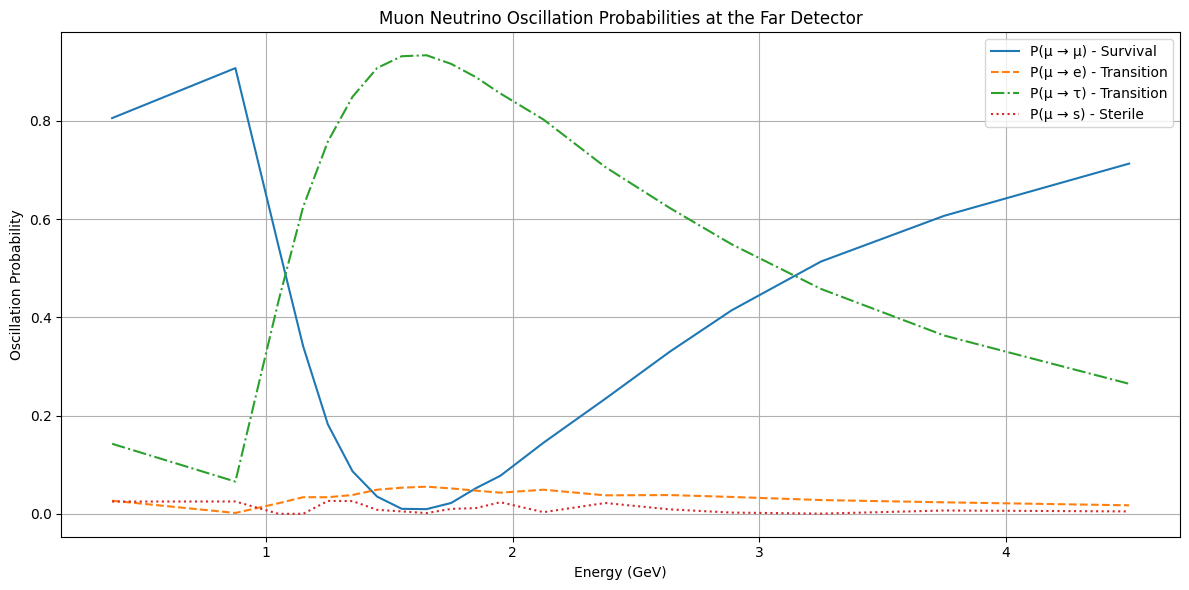

In [ ]:
energy_values = np.linspace(0.1e9, 5e9, 100)

# Plotting the transitions at the near detector
plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, Prob_mm_far, label="P(μ → μ) - Survival", linestyle='-')
plt.plot(bin_centers / 1e9, Prob_me_far, label="P(μ → e) - Transition", linestyle='--')
plt.plot(bin_centers / 1e9, Prob_mt_far, label="P(μ → τ) - Transition", linestyle='-.')
plt.plot(bin_centers / 1e9, Prob_ms_far, label="P(μ → s) - Sterile", linestyle=':')

# Labels and Titles
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("Muon Neutrino Oscillation Probabilities at the Far Detector")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

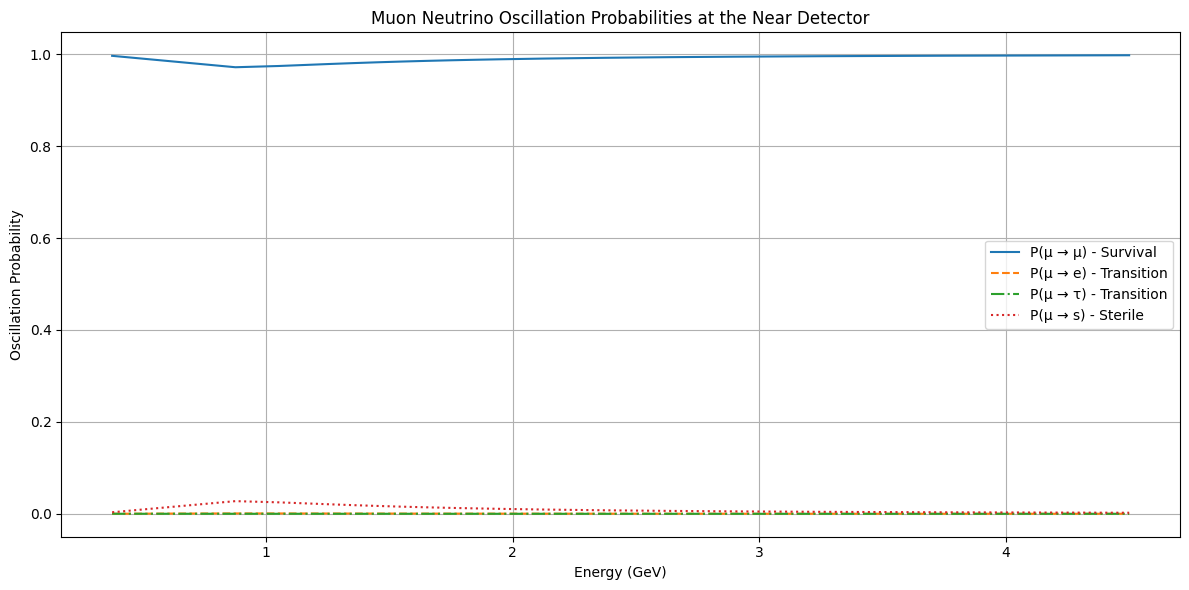

In [ ]:
# Compute oscillation probabilities for the far detector
Prob_mm_near, Prob_me_near, Prob_mt_near, Prob_ms_near = compute_probabilities(Length_near, bin_centers)


# Plotting the transitions at the near detector
plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, Prob_mm_near, label="P(μ → μ) - Survival", linestyle='-')
plt.plot(bin_centers / 1e9, Prob_me_near, label="P(μ → e) - Transition", linestyle='--')
plt.plot(bin_centers / 1e9, Prob_mt_near, label="P(μ → τ) - Transition", linestyle='-.')
plt.plot(bin_centers / 1e9, Prob_ms_near, label="P(μ → s) - Sterile", linestyle=':')

# Labels and Titles
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("Muon Neutrino Oscillation Probabilities at the Near Detector")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

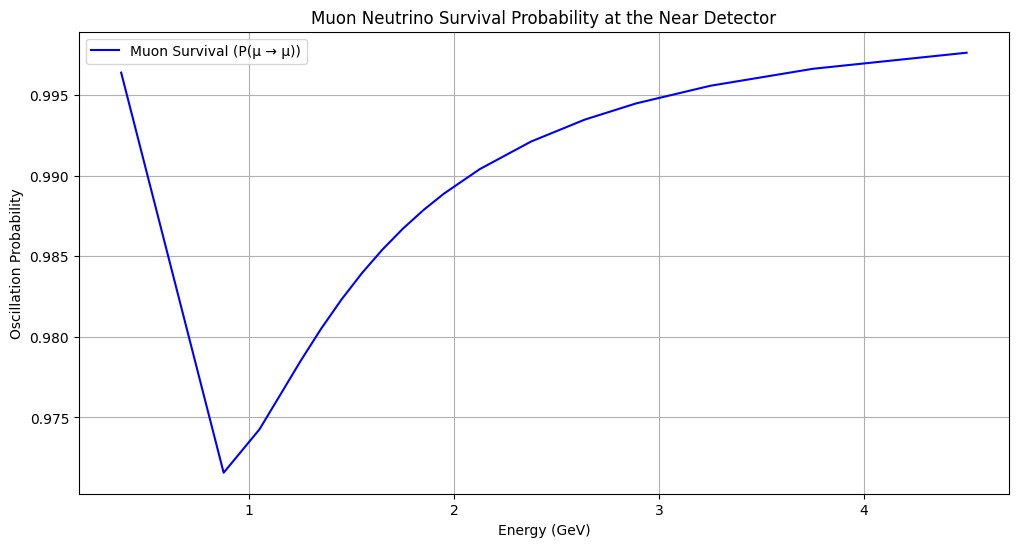

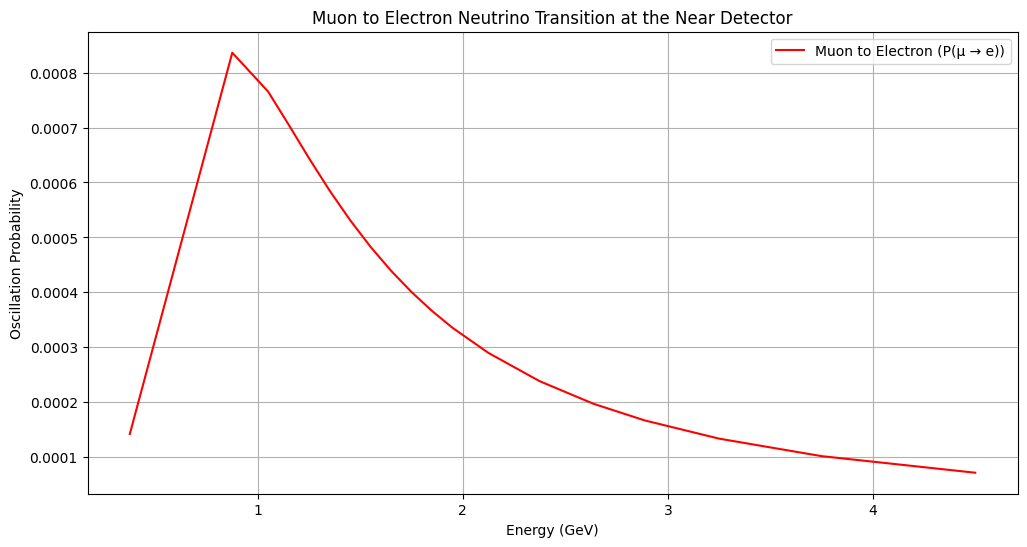

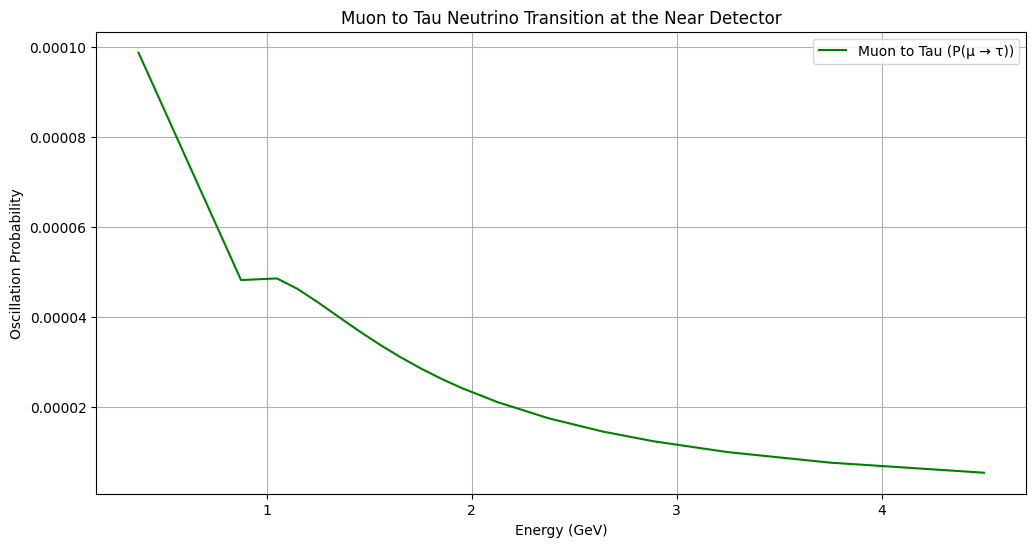

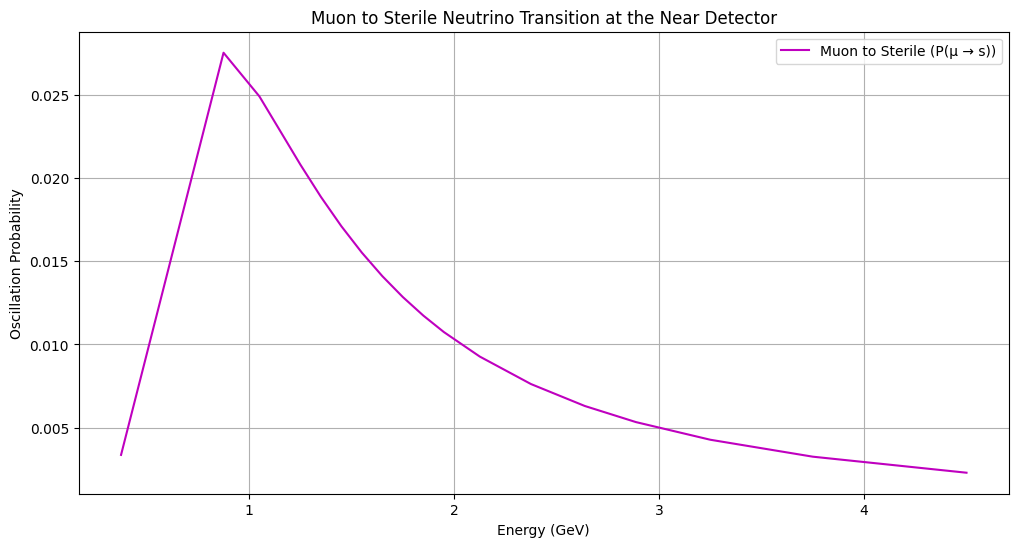

In [ ]:
# Plotting energy spectra for each transition
plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, Prob_mm_near, label="Muon Survival (P(μ → μ))", color='b')
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("Muon Neutrino Survival Probability at the Near Detector")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, Prob_me_near, label="Muon to Electron (P(μ → e))", color='r')
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("Muon to Electron Neutrino Transition at the Near Detector")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, Prob_mt_near, label="Muon to Tau (P(μ → τ))", color='g')
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("Muon to Tau Neutrino Transition at the Near Detector")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(bin_centers / 1e9, Prob_ms_near, label="Muon to Sterile (P(μ → s))", color='m')
plt.xlabel("Energy (GeV)")
plt.ylabel("Oscillation Probability")
plt.title("Muon to Sterile Neutrino Transition at the Near Detector")
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Check probability conservation at each energy value
total_probability_near = Prob_mm_near + Prob_me_near + Prob_mt_near + Prob_ms_near

# Verify if total probability is approximately 1 for all energy values
probability_conserved = np.allclose(total_probability_near, 1, atol=1e-6)

# Output the results
print("Probability is conserved:", probability_conserved)
print("Minimum total probability:", np.min(total_probability_near))
print("Maximum total probability:", np.max(total_probability_near))


Probability is conserved: True
Minimum total probability: 0.9999999999999997
Maximum total probability: 1.0000000000000002


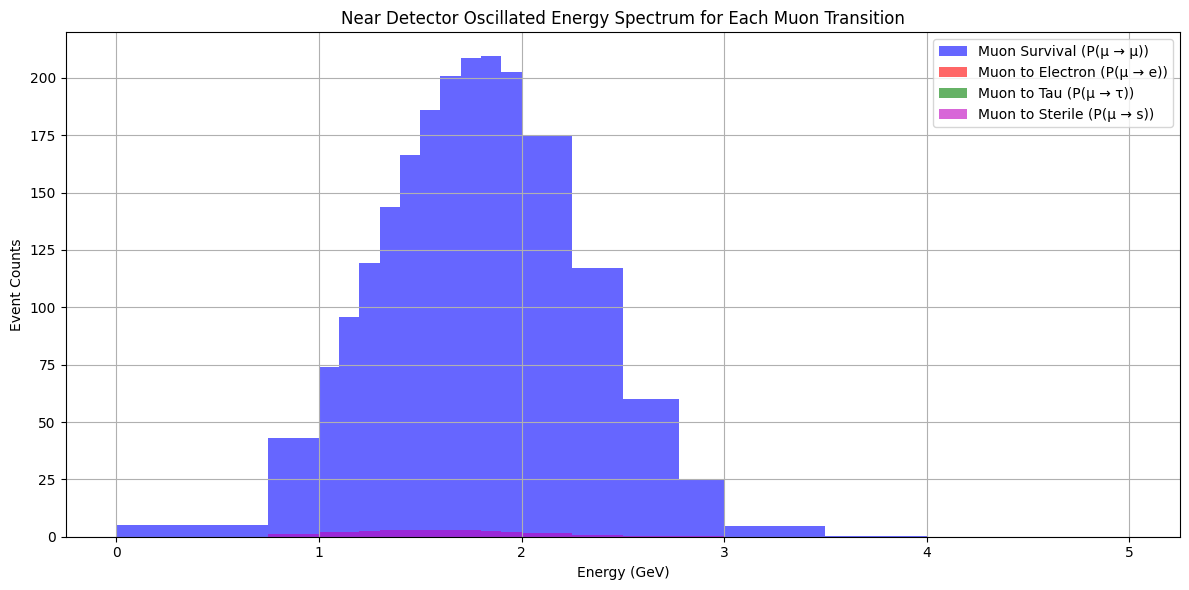

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate energy spectra for each transition at the near detector
oscillated_nd_mu = gaussian(bin_centers, *popt_nd) * Prob_mm_near
oscillated_nd_e = gaussian(bin_centers, *popt_nd) * Prob_me_near
oscillated_nd_tau = gaussian(bin_centers, *popt_nd) * Prob_mt_near
oscillated_nd_sterile = gaussian(bin_centers, *popt_nd) * Prob_ms_near

# Plot Near Detector Energy Spectra for each transition
plt.figure(figsize=(12, 6))

plt.bar(bin_centers / 1e9, oscillated_nd_mu, width=np.diff(bin_edges / 1e9), align="center", alpha=0.6, label="Muon Survival (P(μ → μ))", color="b")
plt.bar(bin_centers / 1e9, oscillated_nd_e, width=np.diff(bin_edges / 1e9), align="center", alpha=0.6, label="Muon to Electron (P(μ → e))", color="r")
plt.bar(bin_centers / 1e9, oscillated_nd_tau, width=np.diff(bin_edges / 1e9), align="center", alpha=0.6, label="Muon to Tau (P(μ → τ))", color="g")
plt.bar(bin_centers / 1e9, oscillated_nd_sterile, width=np.diff(bin_edges / 1e9), align="center", alpha=0.6, label="Muon to Sterile (P(μ → s))", color="m")

plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts")
plt.title("Near Detector Oscillated Energy Spectrum for Each Muon Transition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print(np.max(Prob_me_near))
print(np.max(Prob_mt_near))
print(np.max(Prob_ms_near))
print(np.max(Prob_ms_near))

0.0008361639513823373
9.873782441537624e-05
0.027542626049815392
0.027542626049815392


In [ ]:
print(np.max(Prob_me_far))
print(np.max(Prob_mt_far))
print(np.max(Prob_ms_far))
print(np.max(Prob_ms_far))

0.05530207120038102
0.9335462997484175
0.02628687051810841
0.02628687051810841


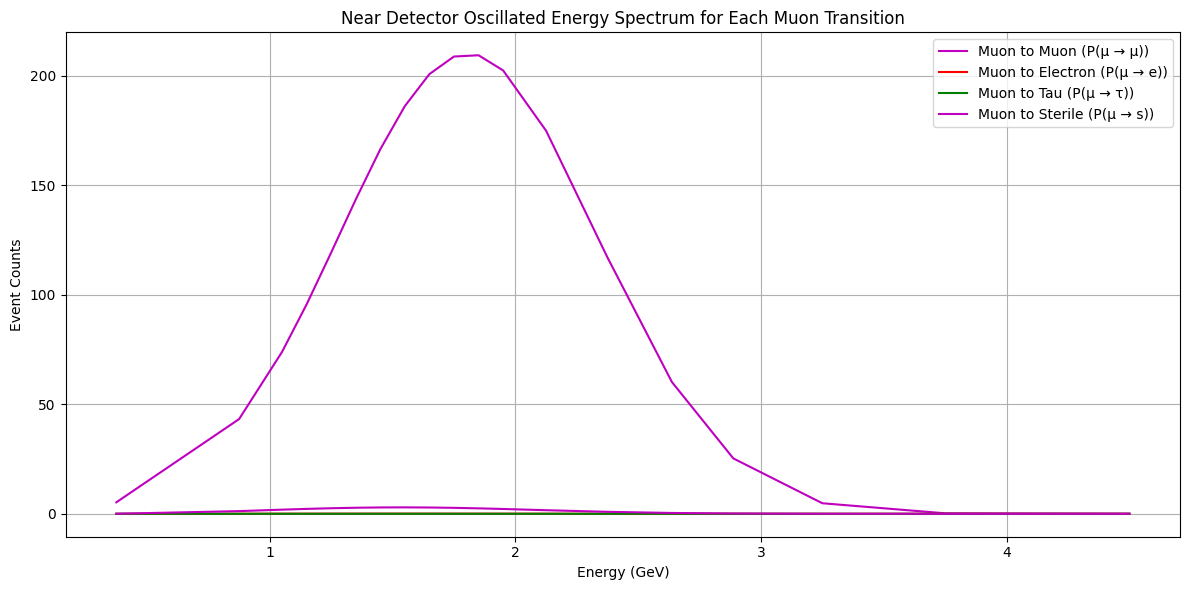

In [ ]:
plt.figure(figsize=(12, 6))


# Plot the transitions as line plots for better visibility
plt.plot(bin_centers / 1e9, oscillated_nd_mu, "m-", label="Muon to Muon (P(μ → μ))")
plt.plot(bin_centers / 1e9, oscillated_nd_e, "r-", label="Muon to Electron (P(μ → e))")
plt.plot(bin_centers / 1e9, oscillated_nd_tau, "g-", label="Muon to Tau (P(μ → τ))")
plt.plot(bin_centers / 1e9, oscillated_nd_sterile, "m-", label="Muon to Sterile (P(μ → s))")

plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts")
plt.title("Near Detector Oscillated Energy Spectrum for Each Muon Transition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
